<a href="https://colab.research.google.com/github/mandakini-15/NLP-Assignment/blob/main/NLP_Assignment_1_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install requests pandas spacy nltk matplotlib wordcloud emoji contractions psaw
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 56.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Importing of the required Libraries

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ne_chunk
from collections import Counter, defaultdict
import pandas as pd
import contractions
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
import emoji
import spacy
from nltk.tokenize import TweetTokenizer, word_tokenize #handles social text tokens like emoticons/lengthening
from nltk.stem import SnowballStemmer #Snowball for English stemming
warnings.filterwarnings('ignore')

# Download required NLTK data
print("Downloading NLTK resources...")
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('punkt_tab') # Added to fix the LookupError

nlp = spacy.load("en_core_web_sm")
tokenizer = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=False)   #preserves emoticons, reduces repeated letters, lowercases via preserve_case flag set False
stemmer = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


**Dataset Details:**

  **Dataset:** Sentiment140 dataset

  **Description:** It containing 1.6 million tweets preprocessed to remove emoticons and ready for sentiment analysis tasks, with labels of 0 (negative) or 4 (positive), ideal for training models to detect polarity in text.
   
  **Source:** Dataset has been downloaded from Kaggle

In [ ]:
c = 'training.1600000.processed.noemoticon.csv' #the local path to dataset
cols = ['target','id','date','flag','user','text']
df = pd.read_csv(c, encoding='latin-1', names=cols, on_bad_lines='skip', engine='python') #reading with latin-1 to handle special characters; use column ordering from dataset
df = df.sample(n=20000, random_state=42).reset_index(drop=True)
df['text'] = df['text'].astype(str)

display(df.head(10))

,target,id,date,flag,user,text
0,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!
1,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo..."
2,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...
3,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...
4,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem
5,0,2052380495,Sat Jun 06 00:32:16 PDT 2009,NO_QUERY,Yengching,Going to miss Pastor's sermon on Faith...
6,4,1983449090,Sun May 31 13:10:36 PDT 2009,NO_QUERY,jessig06,on lunch....dj should come eat with me
7,0,2245479748,Fri Jun 19 16:11:29 PDT 2009,NO_QUERY,felicityfuller,@piginthepoke oh why are you feeling like that?
8,0,1770705699,Mon May 11 22:01:32 PDT 2009,NO_QUERY,stephiiheyy,gahh noo!peyton needs to live!this is horrible
9,4,1970386589,Sat May 30 03:39:34 PDT 2009,NO_QUERY,wyndwitch,@mrstessyman thank you glad you like it! There...


**DATASET PREPARATION**
  

In [ ]:
print("\n\n" + "="*80)
print("Cleaning")
print("="*80)

# Regex definitions
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r'@\w+') # remove @handles
HASHTAG_RE = re.compile(r"#(\w+)")
NON_ALPHANUM_RE = re.compile(r"[^a-zA-Z0-9\s]")
REPEATED_CHARS_RE = re.compile(r"(.)\1{2,}")
ASCII_EMOTICONS = re.compile(r"[:;=8][\-~]?[)(DPpOo/\\]|[)(DPpOo/\\][\-~]?[:;=8]")
PUNCTUATIONS = re.compile(r"[^\w\s]")

def clean_text(text, remove_emoji=True, remove_numbers=True, keep_hashtag_word=True):
    if not isinstance(text, str):
        return ""

    # Expand contractions
    text = contractions.fix(text)

    # Optionally remove emoji; to keep them use emoji.demojize(text)
    if remove_emoji:
        text = emoji.replace_emoji(text, replace='')
    # Remove URLs
    text = URL_RE.sub(" ", text)

    # Remove mentions (rare in YouTube comments but keep for generality)
    text = MENTION_RE.sub(" ", text)

    # Remove extra ASCII emoticons
    text =  ASCII_EMOTICONS.sub('', text)

    # Remove extra Puntuations
    text =  PUNCTUATIONS.sub('', text)

    # Normalize hashtags - keep the word following '#'
    if keep_hashtag_word:
        text = HASHTAG_RE.sub(r"\1", text)
    else:
        text = re.sub(r"#\w+", " ", text)

    # Remove numbers optionally
    if remove_numbers:
        text = re.sub(r"\d+", " ", text)

    # Remove non-alphanumeric (keep spaces)
    text = NON_ALPHANUM_RE.sub(" ", text)

    # Reduce long repeated chars: sooo -> soo
    text = REPEATED_CHARS_RE.sub(r"\1\1", text)

    # Lowercase
    text = text.lower()

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    #Tokenize
    tokens = word_tokenize(text)

    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    return ' '.join(tokens)

# Apply cleaning
df['clean'] = df['text'].apply(clean_text)
print("Original -> Clean (sample):\n")
for i in range(min(5, len(df))):
    print("ORIG:", df.loc[i,'text'])
    print("CLEAN:", df.loc[i,'clean'])
    print("---")
df.head(5)



Cleaning
Original -> Clean (sample):

ORIG: @chrishasboobs AHHH I HOPE YOUR OK!!! 
CLEAN: ahh hope
---
ORIG: @misstoriblack cool , i have no tweet apps  for my razr 2
CLEAN: cool tweet apps razr
---
ORIG: @TiannaChaos i know  just family drama. its lame.hey next time u hang out with kim n u guys like have a sleepover or whatever, ill call u
CLEAN: know family drama lamehey next time hang kim guys like sleepover whatever ill call
---
ORIG: School email won't open  and I have geography stuff on there to revise! *Stupid School* :'(
CLEAN: school email open geography stuff revise stupid school
---
ORIG: upper airways problem 
CLEAN: upper airways problem
---


,target,id,date,flag,user,text,clean
0,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahh hope
1,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo...",cool tweet apps razr
2,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...,know family drama lamehey next time hang kim g...
3,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...,school email open geography stuff revise stupi...
4,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem,upper airways problem


In [ ]:
print("\n\n" + "="*80)
print("Normalization")
print("="*80)

lemmatizer = WordNetLemmatizer()

def normalize_text_lemm(text):
    """
    Normalize text using lemmatization and handle social media specifics
    """
    tokens = word_tokenize(text)

    # Lemmatization
    lemmatized = [lemmatizer.lemmatize(token, pos='v') for token in tokens]
    lemmatized = [lemmatizer.lemmatize(token, pos='n') for token in lemmatized]

    return ' '.join(lemmatized)

df['normalized_text_lemm'] = df['clean'].map(normalize_text_lemm)
df.head(5)

def normalize_text_stem(text):
    """
    Normalize text using stemming
    """
    return " ".join(stemmer.stem(tok) for tok in tokenizer.tokenize(text))

df['normalized_text_stem'] = df['clean'].map(normalize_text_stem)
df.head(5)



Normalization


,target,id,date,flag,user,text,clean,normalized_text_lemm,normalized_text_stem
0,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahh hope,ahh hope,ahh hope
1,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo...",cool tweet apps razr,cool tweet apps razr,cool tweet app razr
2,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...,know family drama lamehey next time hang kim g...,know family drama lamehey next time hang kim g...,know famili drama lamehey next time hang kim g...
3,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...,school email open geography stuff revise stupi...,school email open geography stuff revise stupi...,school email open geographi stuff revis stupid...
4,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem,upper airways problem,upper airway problem,upper airway problem


**POS Tagging and Linguistic Exploration**

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

print("\n\n" + "="*80)
print("POS TAGGING AND LINGUISTIC EXPLORATION")
print("="*80)

# Apply POS tagging
def get_pos_tags(text):
    tokens = word_tokenize(text)
    return pos_tag(tokens)

df['pos_tags'] = df['text'].apply(get_pos_tags)


#Identify posts with specific POS tags
def analyze_pos_patterns(df):
    """Analyze POS patterns that affect tone and style"""

    # Count POS tags per post
    pos_analysis = []
    for idx, row in df.iterrows():
        pos_counts = Counter([tag for _, tag in row['pos_tags']])
        pos_analysis.append({
            'id': row['id'],
            'text': row['text'],
            'interjections': pos_counts.get('UH', 0),
            'adjectives': pos_counts.get('JJ', 0) + pos_counts.get('JJR', 0) + pos_counts.get('JJS', 0),
            'pronouns': pos_counts.get('PRP', 0) + pos_counts.get('PRP$', 0),
            'adverbs': pos_counts.get('RB', 0) + pos_counts.get('RBR', 0) + pos_counts.get('RBS', 0)
        })

    return pd.DataFrame(pos_analysis)

pos_df = analyze_pos_patterns(df)

df.head(5)

print("Posts with HIGH ADJECTIVE usage (emotional/descriptive tone):")
high_adj = pos_df.nlargest(3, 'adjectives')
for _, row in high_adj.iterrows():
    print(f"\nPost #{row['id']} - {row['adjectives']} adjectives")
    print(f"Text: {row['text'][:100]}...")
    tags = df[df['id'] == row['id']]['pos_tags'].values[0]
    adjs = [word for word, tag in tags if tag.startswith('JJ')]
    print(f"Adjectives: {', '.join(adjs)}")

print("Posts with HIGH PRONOUN usage (personal/subjective tone):")
high_pron = pos_df.nlargest(3, 'pronouns')
for _, row in high_pron.iterrows():
    print(f"\nPost #{row['id']} - {row['pronouns']} pronouns")
    print(f"Text: {row['text'][:100]}...")
    tags = df[df['id'] == row['id']]['pos_tags'].values[0]
    prons = [word for word, tag in tags if tag in ['PRP', 'PRP$']]
    print(f"Pronouns: {', '.join(prons)}")

#Syntactic patterns analysis
def extract_syntactic_patterns(df):
    """Extract common syntactic patterns"""

    adj_noun = []
    verb_obj = []
    pron_verb = []

    for idx, row in df.iterrows():
        tags = row['pos_tags']

        for i in range(len(tags) - 1):
            word1, tag1 = tags[i]
            word2, tag2 = tags[i+1]

            # Adjective-Noun pairs
            if tag1.startswith('JJ') and tag2.startswith('NN'):
                adj_noun.append(f"{word1} {word2}")

            # Verb-Object pairs (simplified)
            if tag1.startswith('VB') and tag2.startswith('NN'):
                verb_obj.append(f"{word1} {word2}")

            # Pronoun-Verb combinations
            if tag1 in ['PRP', 'PRP$'] and tag2.startswith('VB'):
                pron_verb.append(f"{word1} {word2}")

    return adj_noun, verb_obj, pron_verb

adj_noun, verb_obj, pron_verb = extract_syntactic_patterns(df)

print("ADJECTIVE-NOUN PAIRS (descriptive expressions):")
adj_noun_counts = Counter(adj_noun).most_common(10)
for pattern, count in adj_noun_counts:
    print(f"  • '{pattern}' - {count} occurrences")

print("VERB-OBJECT PAIRS (action-oriented language):")
verb_obj_counts = Counter(verb_obj).most_common(10)
for pattern, count in verb_obj_counts:
    print(f"  • '{pattern}' - {count} occurrences")

print("PRONOUN-VERB COMBINATIONS (personal expressions):")
pron_verb_counts = Counter(pron_verb).most_common(10)
for pattern, count in pron_verb_counts:
    print(f"  • '{pattern}' - {count} occurrences")

#Discussion on informal language patterns
print("""
LINGUISTIC OBSERVATIONS:

1. INFORMAL & CONVERSATIONAL CHARACTERISTICS:
   • High pronoun usage ('I', 'we', 'our') indicates personal stance and opinions
   • Emotional adjectives ('devastating', 'amazing', 'ridiculous') reveal sentiment
   • Imperative verbs ('act', 'invest', 'learn') show call-to-action patterns
   • Exclamation patterns and repeated punctuation emphasize urgency

2. IMPACT ON NLP TASKS:

   STANCE DETECTION:
   - Pronoun-verb patterns (e.g., 'we need', 'I believe') signal personal stance
   - Modal verbs ('must', 'should', 'can') indicate opinion strength
   - Adjective intensity reveals stance polarity and confidence

   TOXICITY DETECTION:
   - Question patterns with negative adjectives ('Why is...not doing?')
   - Adverbs of intensity ('absolutely', 'still', 'just') amplify emotion
   - All-caps words and repeated punctuation signal aggression/frustration

   SARCASM DETECTION:
   - Adjective-noun mismatches (positive adj + negative context)
   - Ellipsis usage and informal punctuation patterns
   - Pronoun usage in rhetorical questions indicates irony

3. SOCIAL MEDIA SPECIFIC PATTERNS:
   • Hashtags function as topic markers and opinion amplifiers
   • Mentions direct sentiment toward entities (organizations, people)
   • URL presence correlates with informative vs. opinion-based posts
   • Emoticons and repeated characters signal informal, emotional tone
""")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!




POS TAGGING AND LINGUISTIC EXPLORATION
Posts with HIGH ADJECTIVE usage (emotional/descriptive tone):

Post #1880234140 - 11 adjectives
Text: Primary, secondary, tertiary, quaternary, quinary, senary, septenary, octonary, nonary, denary, ??, ...
Adjectives: secondary, tertiary, quaternary, quinary, senary, septenary, octonary, nonary, denary, duodenary, vigenary

Post #2012649651 - 9 adjectives
Text: oh man, oh man, oh man, oh man, oh man, oh man, oh man, oh man... tomorrow is going to be awesome! ...
Adjectives: oh, oh, oh, oh, oh, oh, oh, oh, awesome

Post #2234966292 - 9 adjectives
Text: I stop this and i wish u can talk to me ..And we can be ok again  imm leave u alone it till u r ok a...
Adjectives: i, wish, .., imm, u, u, less, i, u
Posts with HIGH PRONOUN usage (personal/subjective tone):

Post #1956357898 - 10 pronouns
Text: I said I make you smile for the simple fact I'm good at it, I make you smile so I can sit there and ...
Pronouns: I, I, you, I, it, I, you, I, it, ya

Pos

**VISUALIZATION**

Visualizations saved as 'pos_visualizations.png'


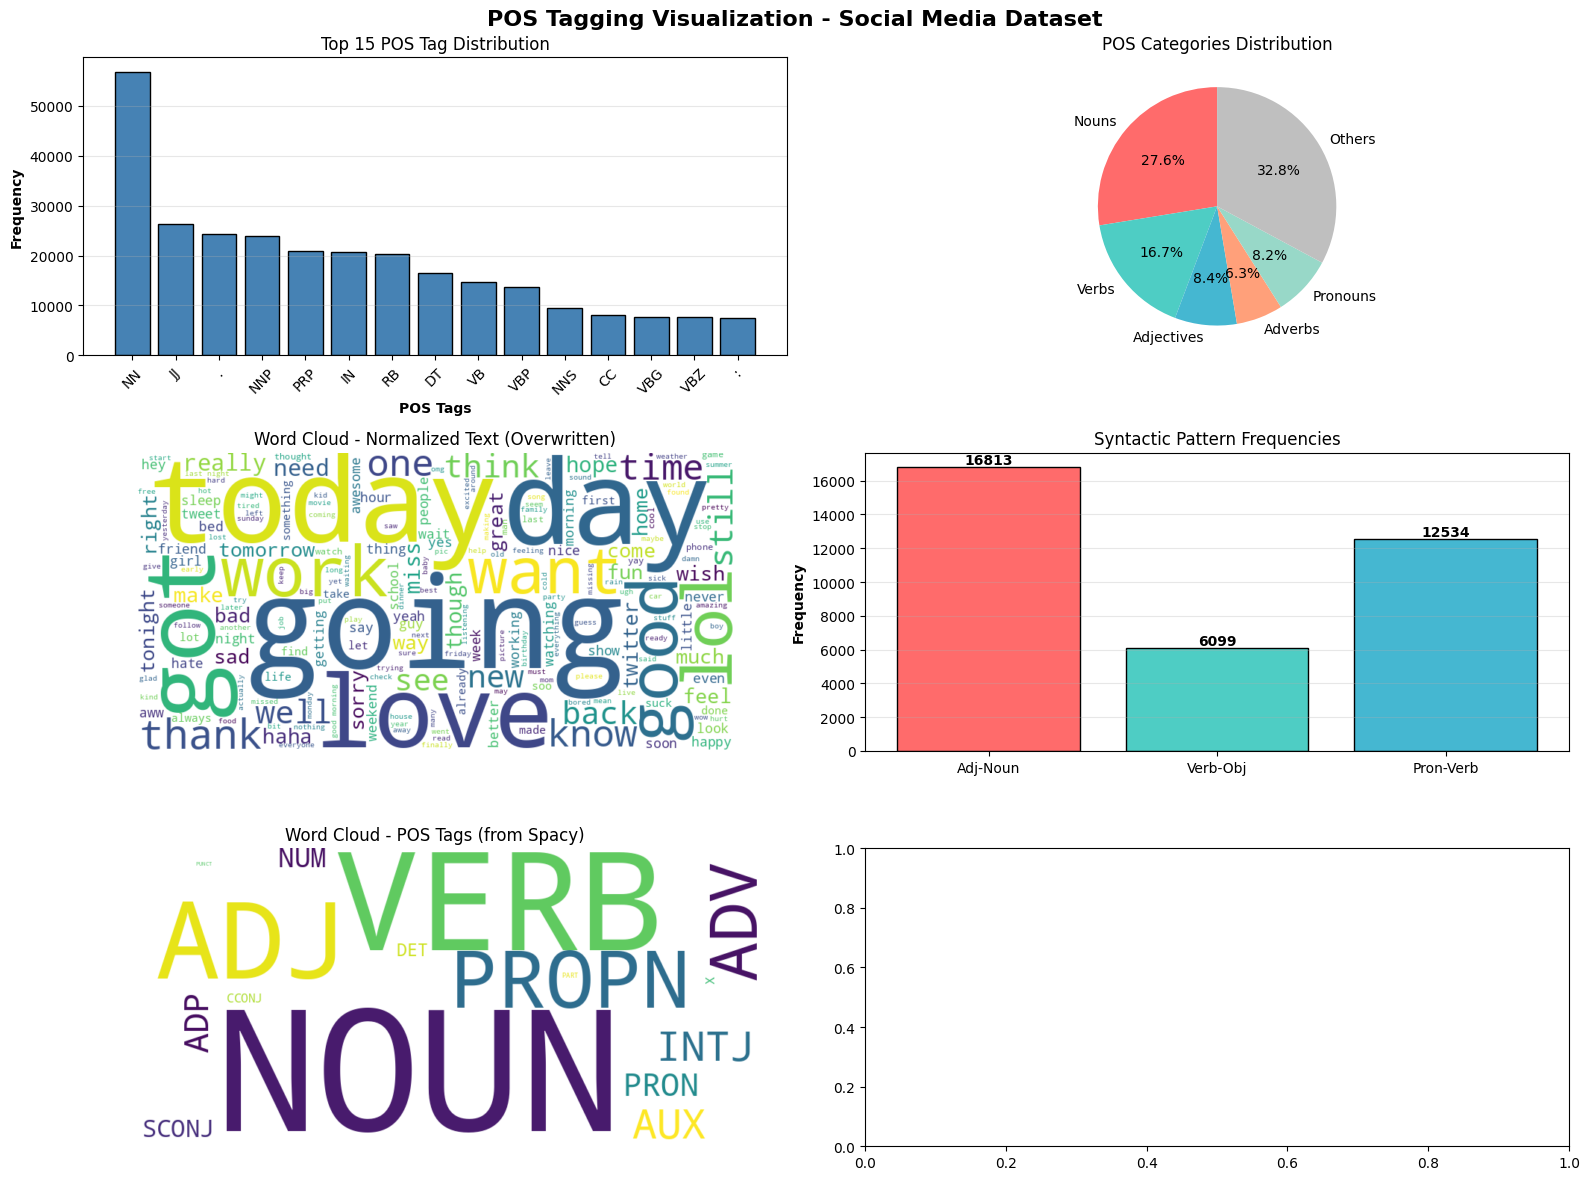

In [ ]:
# Collect all POS tags
all_pos_tags = []
for tags in df['pos_tags']:
    all_pos_tags.extend([tag for _, tag in tags])

pos_counts = Counter(all_pos_tags)

# Create visualizations
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('POS Tagging Visualization', fontsize=16, fontweight='bold')

#Bar chart of POS distribution
ax1 = axes[0, 0]
top_pos = dict(pos_counts.most_common(15))
ax1.bar(top_pos.keys(), top_pos.values(), color='steelblue', edgecolor='black')
ax1.set_xlabel('POS Tags', fontweight='bold')
ax1.set_ylabel('Frequency', fontweight='bold')
ax1.set_title('Top 15 POS Tag Distribution')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

#POS category grouping
ax2 = axes[0, 1]
pos_categories = {
    'Nouns': sum([pos_counts[tag] for tag in pos_counts if tag.startswith('NN')]),
    'Verbs': sum([pos_counts[tag] for tag in pos_counts if tag.startswith('VB')]),
    'Adjectives': sum([pos_counts[tag] for tag in pos_counts if tag.startswith('JJ')]),
    'Adverbs': sum([pos_counts[tag] for tag in pos_counts if tag.startswith('RB')]),
    'Pronouns': sum([pos_counts[tag] for tag in pos_counts if tag in ['PRP', 'PRP$']]),
    'Others': sum([count for tag, count in pos_counts.items() if not any(tag.startswith(x) for x in ['NN', 'VB', 'JJ', 'RB']) and tag not in ['PRP', 'PRP$']])
}
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#BFBFBF']
ax2.pie(pos_categories.values(), labels=pos_categories.keys(), autopct='%1.1f%%',
        colors=colors_pie, startangle=90)
ax2.set_title('POS Categories Distribution')

#Word cloud from normalized text
ax_normal_wc = axes[1, 0] # Renamed ax3 to avoid confusion with the subsequent overwrite
all_text_normal = ' '.join(df['clean'])
wordcloud_normal = WordCloud(width=800, height=400, background_color='white',colormap='viridis').generate(all_text_normal)
ax_normal_wc.imshow(wordcloud_normal, interpolation='bilinear')
ax_normal_wc.axis('off')
ax_normal_wc.set_title('Word Cloud - Normalized Text')

#Word cloud from pos_tag
pc = Counter() # This Counter is populated by Spacy POS tags from 'clean' text
for txt in df['clean'].astype(str):
    d = nlp(txt)
    for tok in d:
        pc[tok.pos_] += 1

# pos_df is created from pc, but not directly used by generate_from_frequencies
pos_df = pd.DataFrame(pc.items(), columns=['POS','count']).sort_values('count', ascending=False)

# Use the same subplot axes[1,0] for the POS tag word cloud, overwriting the previous one.
ax_pos_wc = axes[2, 0] # Renamed ax3 for clarity

# Generate word cloud from the frequencies in 'pc'
wordcloud_postags = WordCloud(width=900, height=400, background_color='white', collocations=False).generate_from_frequencies(pc)
ax_pos_wc.imshow(wordcloud_postags, interpolation='bilinear')
ax_pos_wc.axis('off')
ax_pos_wc.set_title('Word Cloud - POS Tags')

#Syntactic pattern frequency
ax4 = axes[1, 1]
pattern_types = ['Adj-Noun', 'Verb-Obj', 'Pron-Verb']
pattern_counts = [len(adj_noun), len(verb_obj), len(pron_verb)]
colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax4.bar(pattern_types, pattern_counts, color=colors_bar, edgecolor='black')
ax4.set_ylabel('Frequency', fontweight='bold')
ax4.set_title('Syntactic Pattern Frequencies')
ax4.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('pos_visualizations.png', dpi=300, bbox_inches='tight')
print("Visualizations saved as 'pos_visualizations.png'")